In [10]:
import pandas as pd
import numpy as np
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [11]:
df_train_raw = pd.read_csv('../data/raw/train.csv').drop('Id', axis=1)
df_train = df_train_raw.copy()
print(f'start dimentions --> {df_train_raw.shape}')
df_train_raw.head()

start dimentions --> (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
#Analisis de datos faltantes
missing_data = df_train_raw.isnull().sum()
missing_data = pd.DataFrame(missing_data[missing_data > 0], columns=['missing_count'])
missing_data['missing_percentage (%)'] = np.round(missing_data['missing_count'] / df_train_raw.shape[0] * 100, 2)
missing_data = missing_data.sort_values(by='missing_count', ascending=False)
print('fields with missing data:')
missing_data

fields with missing data:


,missing_count,missing_percentage (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [13]:
#Manejo de datos faltantes
#Paso inicial eliminar las columnas que tienen mas del 80% de datos faltantes

#Alley: El tipo de acceso al callejón.
#MasVnrType: El tipo de revestimiento de mampostería.
#FireplaceQu: La calidad de la chimenea.
#PoolQC: La calidad de la piscina.
#Fence: La calidappd de la valla.
#MiscFeature: Una característica miscelánea no cubierta en otras categorías.

print(f'start dimentions {df_train.shape}')
initial_columns = df_train.columns
df_train = df_train.dropna(thresh=len(df_train) * 0.8, axis=1)
columns_deleted = [col for col in initial_columns if col not in df_train.columns]
print(f'columns deleted ({len(columns_deleted)}) --> {columns_deleted}')

start dimentions (1460, 80)
columns deleted (6) --> ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [14]:
#Columnas con datos faltantes resultantes de la eliminacion anterior
missing_res_deleted = df_train.isnull().sum()
missing_res_deleted = missing_res_deleted[missing_res_deleted > 0].sort_values(ascending=True)
print(f'numero de columnas con datos faltantes --> {len(missing_res_deleted)}')
missing_res_deleted

numero de columnas con datos faltantes --> 13


Electrical        1
MasVnrArea        8
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
BsmtExposure     38
BsmtFinType2     38
GarageType       81
GarageCond       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
LotFrontage     259
dtype: int64

In [15]:
#imputacion simple
#Electrical: El sistema eléctrico. -> Valores faltantes imputados con la moda
df_train['Electrical'] = df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])
#MasVnrArea: Área de revestimiento de mampostería en pies cuadrados. -> Valores faltantes imputados con (0)
df_train['MasVnrArea'] = df_train['MasVnrArea'].fillna(0)

In [16]:
#Variables relacionadas con el sótano

#BsmtQual: Evalúa la altura del sótano.
#BsmtCond: Evalúa la condición general del sótano.
#BsmtExposure: Refleja la cantidad de exposición al sótano al aire exterior.
#BsmtFinType1: Evaluación del tipo de acabado del sótano.
#BsmtFinSF1: Metros cuadrados del sótano terminado en el tipo 1.
#BsmtFinType2: Evaluación del tipo de acabado del sótano (si hay dos tipos).
#BsmtFinSF2: Metros cuadrados del sótano terminado en el tipo 2.
#BsmtUnfSF: Metros cuadrados del sótano sin terminar.
#TotalBsmtSF: Metros cuadrados totales del sótano.
#BsmtFullBath: Número de baños completos en el sótano.
#BsmtHalfBath: Número de medios baños en el sótano.
bsmt = df_train.filter(like='Bsmt')
bsmt

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
0,Gd,TA,No,GLQ,706,Unf,0,150,856,1,0
1,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,0,1
2,Gd,TA,Mn,GLQ,486,Unf,0,434,920,1,0
3,TA,Gd,No,ALQ,216,Unf,0,540,756,1,0
4,Gd,TA,Av,GLQ,655,Unf,0,490,1145,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1455,Gd,TA,No,Unf,0,Unf,0,953,953,0,0
1456,Gd,TA,No,ALQ,790,Rec,163,589,1542,1,0
1457,TA,Gd,No,GLQ,275,Unf,0,877,1152,0,0
1458,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,1,0


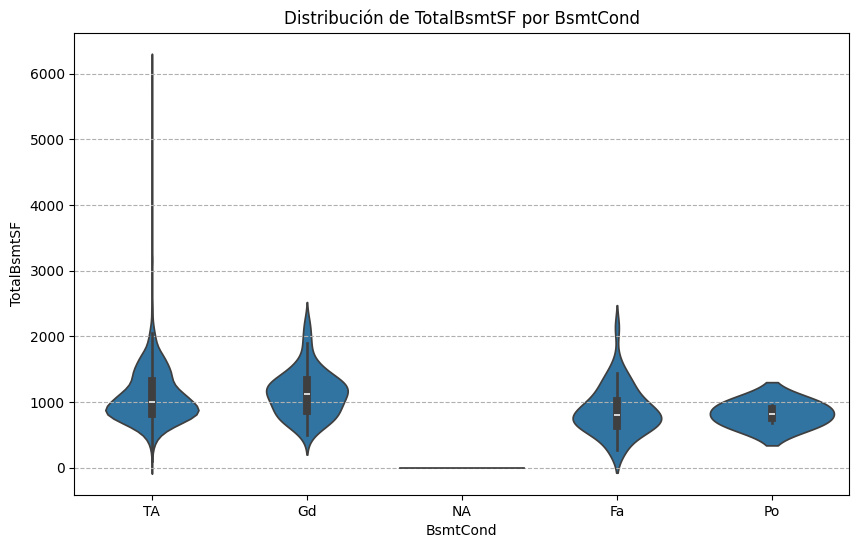

In [17]:
cond_not_basement = (df_train['TotalBsmtSF'] == 0) & (df_train['BsmtUnfSF'] == 0)
#BsmtCond: Evalúa la condición general del sótano. -> (NA) no tiene sótano
#BsmtQual: Evalúa la altura del sótano. -> (NA) no tiene sótano
##BsmtFinType1: Evaluación del tipo de acabado del sótano. -> (NA) no tiene sótano
#BsmtExposure: Refleja la cantidad de exposición al sótano al aire exterior. -> (NA) no tiene sótano
#BsmtFinType2: Evaluación del tipo de acabado del sótano (si hay dos tipos). -> (NA) no tiene sótano
cols_not_basement = ['BsmtCond', 'BsmtQual', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']
df_train.loc[cond_not_basement, cols_not_basement] = df_train.loc[cond_not_basement, cols_not_basement].fillna('NA')
plt.figure(figsize=(10, 6))
sns.violinplot(x='BsmtCond', y='TotalBsmtSF', data=df_train)
plt.title('Distribución de TotalBsmtSF por BsmtCond')
plt.xlabel('BsmtCond')
plt.ylabel('TotalBsmtSF')
plt.grid(axis='y', linestyle='--')

105
6110
count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64


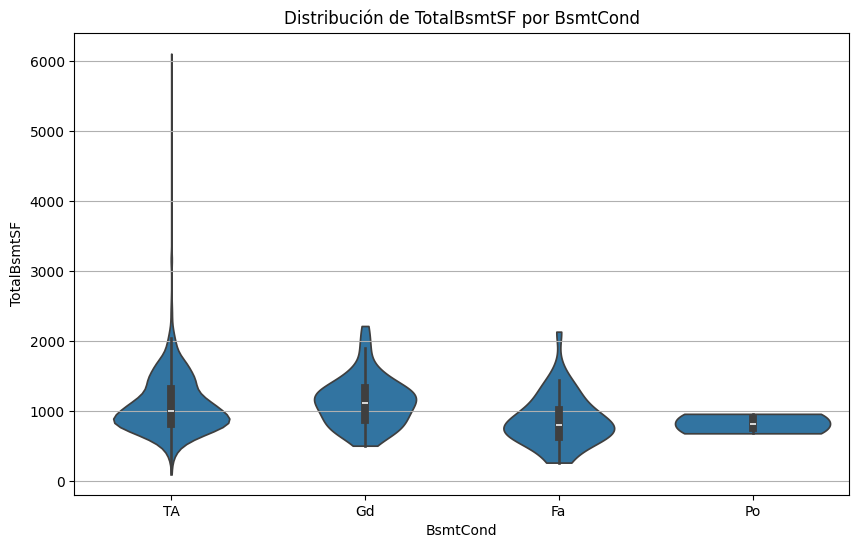

In [33]:
bsmt_greater_than_0 = df_train[(df_train['TotalBsmtSF'] > 0)].filter(like='Bsmt')
print(bsmt_greater_than_0['TotalBsmtSF'].min())
print(bsmt_greater_than_0['TotalBsmtSF'].max())
print(df_train['TotalBsmtSF'].describe())
bsmt_greater_than_0
plt.figure(figsize=(10, 6))
sns.violinplot(x='BsmtCond', y='TotalBsmtSF', data=bsmt_greater_than_0[bsmt_greater_than_0['TotalBsmtSF'] > 0], cut=0)
plt.title('Distribución de TotalBsmtSF por BsmtCond')
plt.xlabel('BsmtCond')
plt.ylabel('TotalBsmtSF')
plt.grid(axis='y')